<a href="https://colab.research.google.com/github/rowandama/DataSciSum2/blob/main/Big5_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cleaning

In [5]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/collar/data-final.csv', sep='\t')
trait_prefixes = ['EXT', 'EST', 'AGR', 'CSN', 'OPN']
item_cols = [c for c in df.columns if any(c.startswith(p) and c[len(p):].isdigit() for p in trait_prefixes)]
reverse_items = ['EXT2','EXT4','EXT6','EXT8','EXT10','EST2','EST4','AGR1','AGR3','AGR5','AGR7','CSN2','CSN4','CSN6','CSN8','OPN2','OPN4','OPN6'] # reverse coding the reverse questions, these are available to see in full in the txt file from the kaggle download
df = df.dropna(subset=item_cols) # dropping the missing values but just from the questionaire column, havent got around to thinking about the demogs get so burn that bridge when we get to it
df = df.drop_duplicates() # was with the dropping missing values - cause the dataset is so massive i feel justified in just dropping dupilcates because its unlikley people have exactly the same scores across a 50 point questionaire
for item in reverse_items: #reversing the flipped questions
  df[item] = 5 - df[item]
  row_std = df[item_cols].std(axis=1)
df = df[row_std > 0]  # drop straight-liners likely bots??
df = df[(df['testelapse'] >= 120) & (df['testelapse'] <= 3600)]  # removing really slow or really fast completion times-to get rid of possible bots/carelessness
# after all this I have no missing values, removed most obvious bot answers and 222 counties, mostly usa answers all of my vlues in the items are between 0-5

# Exploration
for this im going to use visualisation with plotting the distribution with boxplots and histograms and then look correlation heatmaps for the traits and the items.

In [6]:
traits_map = {
    'Extraversion': [c for c in item_cols if c.startswith('EXT')],
    'Neuroticism': [c for c in item_cols if c.startswith('EST')],
    'Agreeableness': [c for c in item_cols if c.startswith('AGR')],
    'Conscientiousness': [c for c in item_cols if c.startswith('CSN')],
    'Openness': [c for c in item_cols if c.startswith('OPN')] }
for trait, cols in traits_map.items():
    df[trait] = df[cols].mean(axis=1).round(2)

traits = ['Extraversion', 'Neuroticism', 'Agreeableness', 'Conscientiousness', 'Openness']


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

## Histograms and boxplots

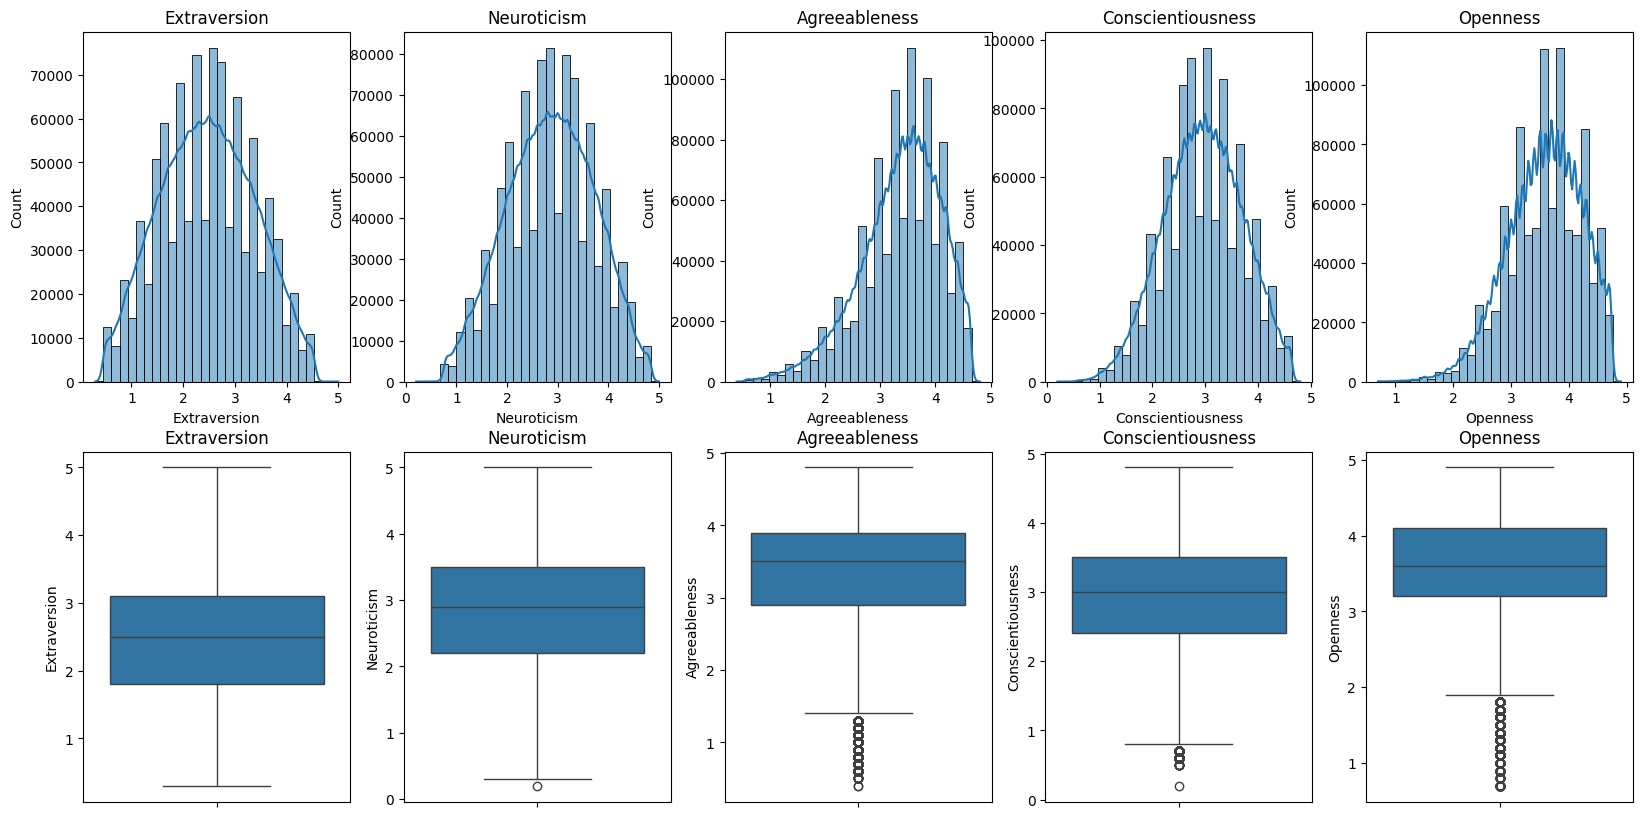

In [8]:
#histogram and boxplot
fig, axes = plt.subplots(2, 5, figsize=(20, 10))

for i, trait in enumerate(traits):
    sns.histplot(df[trait], bins=30, kde=True, ax=axes[0, i]).set_title(trait)
    sns.boxplot(y=df[trait], ax=axes[1, i]).set_title(trait)

plt.show()

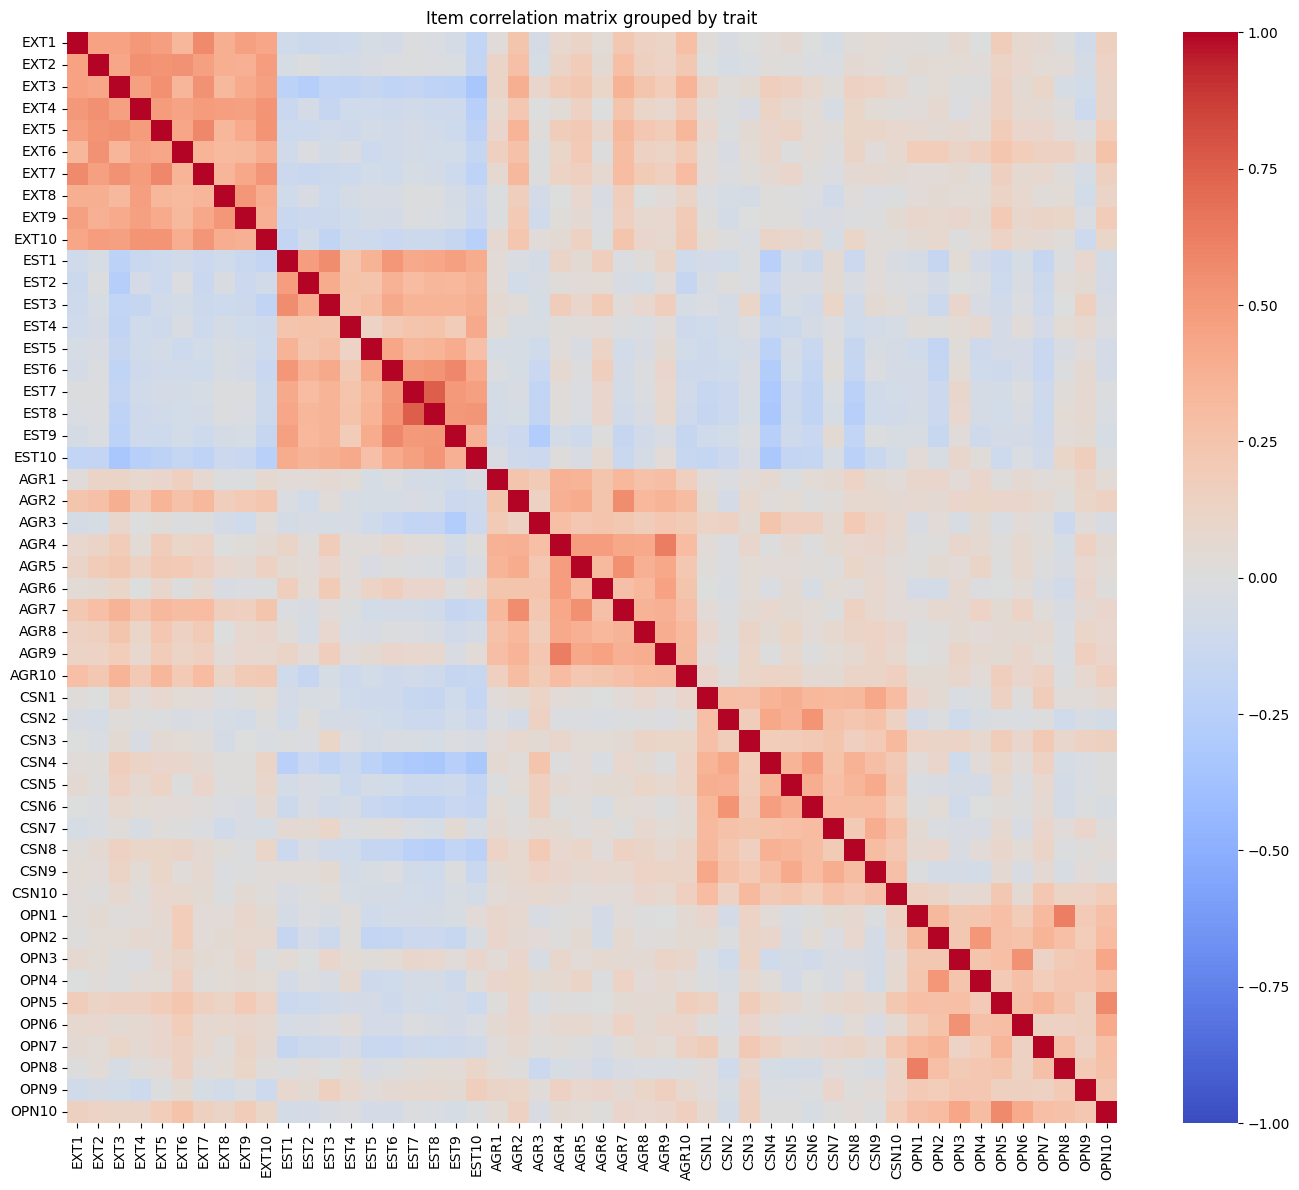

In [12]:
# all item correlation map
item_corr = df[item_cols].corr()
plt.figure(figsize=(14, 12))
sns.heatmap(item_corr, cmap='coolwarm', vmin=-1, vmax=1) # the vim/max stop it auto-creating its own zoomed in bit of scale
plt.title('Item correlation matrix grouped by trait')
plt.tight_layout()

plt.show()

In [13]:
# this is so i can make interactive visulaisations in html
import os
os.makedirs('output', exist_ok=True)


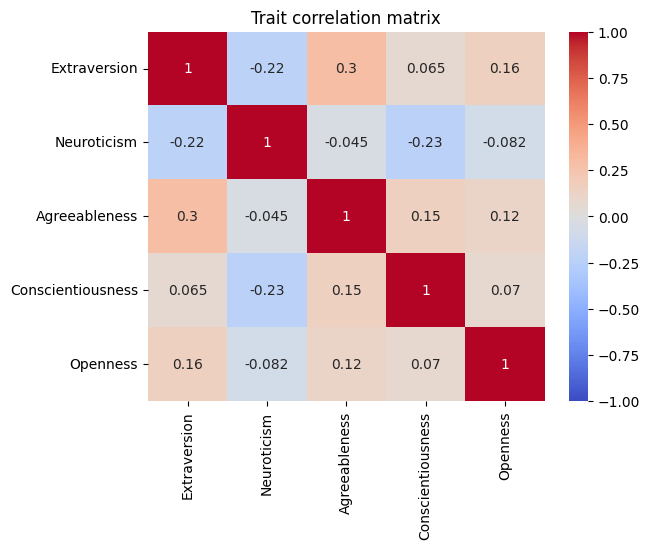

In [14]:
# trait correlation map
trait_corr = df[traits].corr()

sns.heatmap(trait_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Trait correlation matrix')

plt.show()

In [15]:
import plotly.graph_objects as go
import plotly.express as px

# radar chart of average trait scores
avg_scores = df[traits].mean()
fig = go.Figure()
fig.add_trace(go.Scatterpolar(r=avg_scores.values, theta=traits, fill='toself', name='Average'))
fig.update_layout(polar=dict(radialaxis=dict(visible=True, range=[0, 5])),
                   title='Average Big Five trait scores')
fig.write_html('output/radar_chart.html')
fig.show()



In [16]:
fig2 = px.scatter_matrix(
    df.sample(10000, random_state=42),
    dimensions=traits,
    opacity=0.4,
    title='Scatter matrix of Big Five traits'
)

fig2.update_traces(diagonal_visible=False, marker=dict(size=3))
fig2.update_layout(width=1000, height=1000)
fig2.write_html('output/scatter_matrix.html')
fig2.show()

## Interactive visualisation
Now I want to see the comparison of average traist scores but filtered by country to see if there is an interesting level of variation.

Key steps
- only use countried with at least 200 responses
- need to convert the country codes to ISO-3 so pycountry can understand it


! obviously the usa creates more of a country wide average then all the rest because it has so many more respondents so most of these averages are only in realtion to the data collecated and no assumptions or conclusions can be drawn from them!!!

In [26]:
pip install pycountry

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 36.4 MB/s eta 0:00:00


In [27]:
import pycountry

In [74]:
# making average scores for each trait for each country and converting country codes and cutting out places without enough answers
country_avg = df.groupby('country')[traits].mean().round(2).reset_index()
country_counts = df['country'].value_counts()
valid_countries = country_counts[country_counts >= 200].index
country_avg = country_avg[country_avg['country'].isin(valid_countries)]

country_avg['iso3'] = country_avg['country'].apply(to_iso3)
country_avg = country_avg.dropna(subset=['iso3'])

In [75]:
fig3 = go.Figure()
for i, trait in enumerate(traits):
    fig3.add_trace(go.Choropleth(
    locations=country_avg['iso3'], locationmode='ISO-3', z=country_avg[trait],
    colorscale='Plasma', colorbar_title=trait, visible=(i == 0), name=trait    ))
fig3.update_layout(
     title='average trait score by country',
     geo=dict(projection_type='orthographic', showland=True, landcolor='lightgray',
              showocean=True, oceancolor='azure'),
         updatemenus=[dict(
             buttons=[dict(label=trait, method='update',
                           args=[{'visible': [t == trait for t in traits]},
                                 {'title': f'Average {trait} by country'}]) for trait in traits],
                     direction='down', x=0.1, y=1.1    )] )
fig3.write_html('output/trait_globe.html')
fig3.show()

# Factor analysis
Are the big 5 real?

In [41]:
!pip install factor_analyzer

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 kB 1.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for factor_analyzer: filename=factor_analyzer-0.5.1-py2.py3-none-any.whl size=42657 sha256=e46215a71507e1bc304a06faae1d5730f0854e0855363ced3807f28f05f3a86a
  Stored in directory: /root/.cache/pip/wheels/a2/af/06/f4d4ed4d9d714fda437fb1583629417319603c2266e7b233cc
Successfully built factor_analyzer


### Checks
To first check if factor analysis is worth doing I use bartlets test of spherity to see if the items are correlated and the Kaiser-Meyer-Olkin (KMO) test to see if this correlation is appropriate for factor extracting

In [42]:
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity, calculate_kmo

chi_square_value, p_value = calculate_bartlett_sphericity(df[item_cols])
kmo_all, kmo_model = calculate_kmo(df[item_cols])
print(f"bartlett's test p-value: {p_value}")
print(f"KMO overall: {kmo_model}")

Bartlett's test p-value: 0.0
KMO overall: 0.9076886640680437


this is good! it means this data is suitible
Now I want to use the eigen values / scree plot to see where the elbow is and how many factors to look at. Either I can focous on the 5 were working with from the premise of the data or maybe theres more?

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



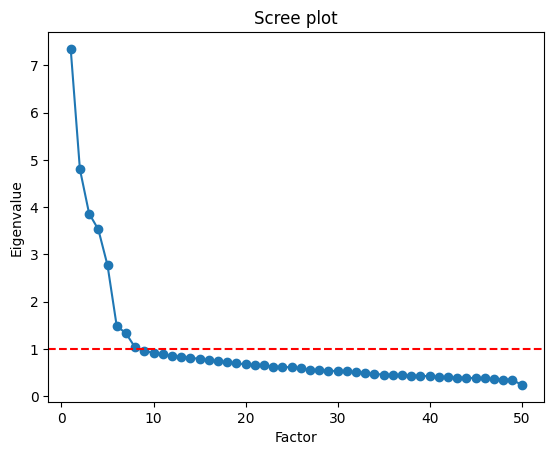

In [45]:
from factor_analyzer import FactorAnalyzer
import matplotlib.pyplot as plt

fa = FactorAnalyzer(rotation=None)
fa.fit(df[item_cols])
ev, v = fa.get_eigenvalues()

plt.scatter(range(1, len(ev)+1), ev)
plt.plot(range(1, len(ev)+1), ev)
plt.axhline(y=1, color='r', linestyle='--')
plt.title('Scree plot')
plt.xlabel('Factor')
plt.ylabel('Eigenvalue')
plt.show()

Now visually you can see this indiactes up to 8 factors could explain the variance. HEXACO for example uses 6. But the questions that created this data do not have any questions that could be used to measure the honesty component that hexaco has. But lets just have a look to see if six factors would make sense and how it would be grouped if we used 6

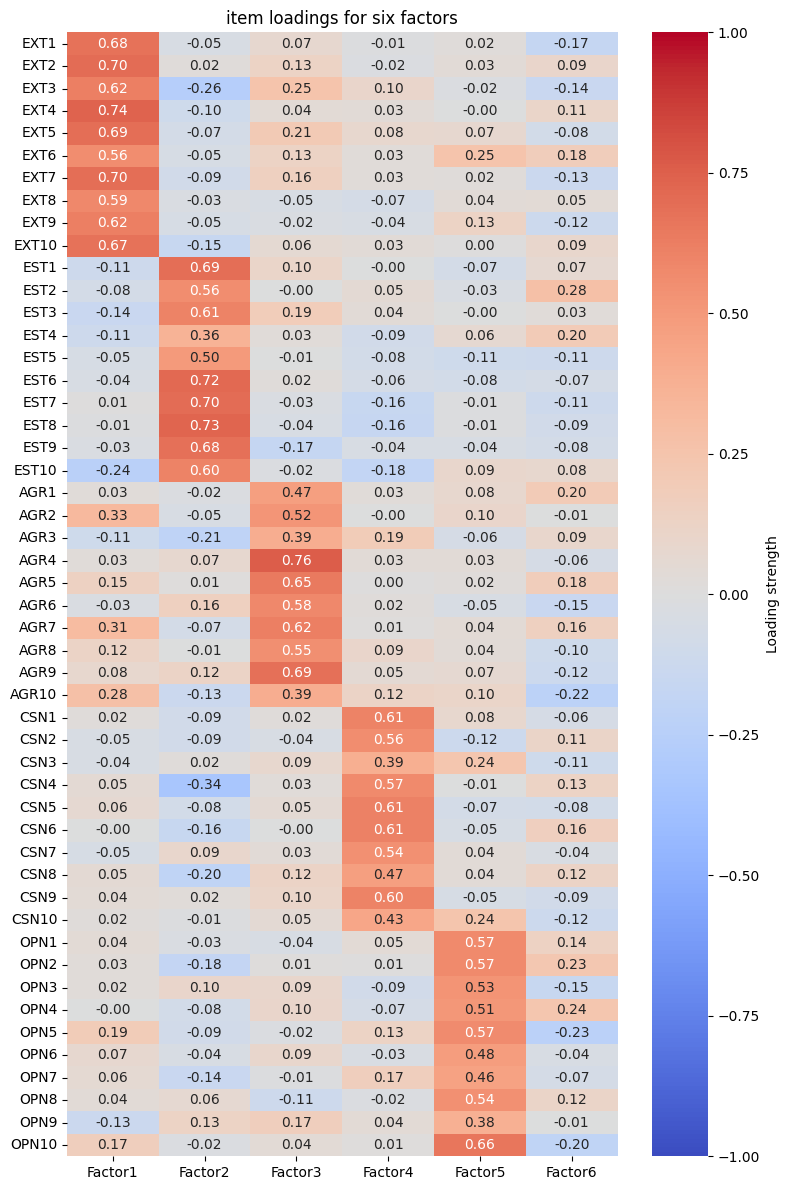

In [67]:

loadings6 = pd.DataFrame(fa6.loadings_, index=item_cols,
                          columns=[f'Factor{i+1}' for i in range(6)])

plt.figure(figsize=(8, 12))
sns.heatmap(loadings6, cmap='coolwarm', center=0, annot=True, fmt='.2f',
            vmin=-1, vmax=1, cbar_kws={'label': 'Loading strength'})
plt.title('item loadings for six factors')
plt.tight_layout()

plt.show()

now this does not look good at all! there is no obvious density of correlation in a possible 6th factor. For me this confirms that the questions in this survey sucsessfuly ask themselves within 5 parameters. This regects the hypothisis of there being 6 factors studied in this data. That of course does not make any comment about the validity or nature of personalities in relation to the big 5 just about what this data is looking at!!!

# Final Hypothesis
Now I want to test another hypotheis to see if I can find something interesting. In the exploratory phase I saw on the globe that there was visual difference across the globe that looked grouped. Inspired by a friends capstone about language making things feel differently I have decided to see if the factor structure is mirrored between englush and non englishspeaking countries.

In [60]:
anglophone_countries = ['US', 'GB', 'CA', 'AU', 'NZ', 'IE']

df['group'] = df['country'].apply(
    lambda c: 'Anglophone' if c in anglophone_countries else 'Non-Anglophone'
)

print(df['group'].value_counts())

group
Anglophone        701772
Non-Anglophone    258997
Name: count, dtype: int64


In [61]:
from factor_analyzer import FactorAnalyzer
import pandas as pd
import numpy as np

def run_fa(data, item_cols, n_factors=5):
    fa = FactorAnalyzer(n_factors=n_factors, rotation='varimax')
    fa.fit(data[item_cols])
    return pd.DataFrame(fa.loadings_, index=item_cols,
                         columns=[f'Factor{i+1}' for i in range(n_factors)])

anglo_loadings = run_fa(df[df['group'] == 'anglophone'], item_cols)
non_anglo_loadings = run_fa(df[df['group'] == 'non-anglophone'], item_cols)

print(anglo_loadings.round(2)) # always round 2 otherwise such silly long numbers ahah
print(non_anglo_loadings.round(2))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



       Factor1  Factor2  Factor3  Factor4  Factor5
EXT1      0.70    -0.04     0.06    -0.02     0.02
EXT2      0.70     0.02     0.13    -0.02     0.03
EXT3      0.63    -0.27     0.24     0.09    -0.02
EXT4      0.75    -0.11     0.05     0.03    -0.00
EXT5      0.70    -0.08     0.21     0.08     0.07
EXT6      0.56    -0.04     0.14     0.03     0.24
EXT7      0.71    -0.09     0.15     0.02     0.01
EXT8      0.60    -0.03    -0.04    -0.08     0.05
EXT9      0.65    -0.05    -0.03    -0.06     0.14
EXT10     0.68    -0.16     0.07     0.03     0.01
EST1     -0.11     0.70     0.11    -0.00    -0.08
EST2     -0.09     0.55     0.01     0.04    -0.03
EST3     -0.14     0.62     0.18     0.04    -0.02
EST4     -0.14     0.40     0.03    -0.11     0.07
EST5     -0.04     0.49     0.00    -0.06    -0.12
EST6     -0.03     0.72     0.03    -0.06    -0.09
EST7      0.02     0.71    -0.04    -0.16    -0.01
EST8      0.00     0.74    -0.05    -0.16    -0.02
EST9     -0.02     0.69    -0.1

In [65]:
# now i want to see if there is much difference in the loadings between each group because that list is incomprehensible to me
loading_diff = (anglo_loadings - non_anglo_loadings).abs()
print(loading_diff.max(axis=1).sort_values(ascending=False).head(10))

Average absolute loading difference: 0.11565672472894885
Items with largest structural difference:
CSN5     0.696371
CSN2     0.680037
CSN9     0.667624
CSN6     0.661569
OPN10    0.652717
OPN3     0.620315
OPN8     0.604352
OPN2     0.592815
OPN4     0.590520
CSN4     0.582380
dtype: float64


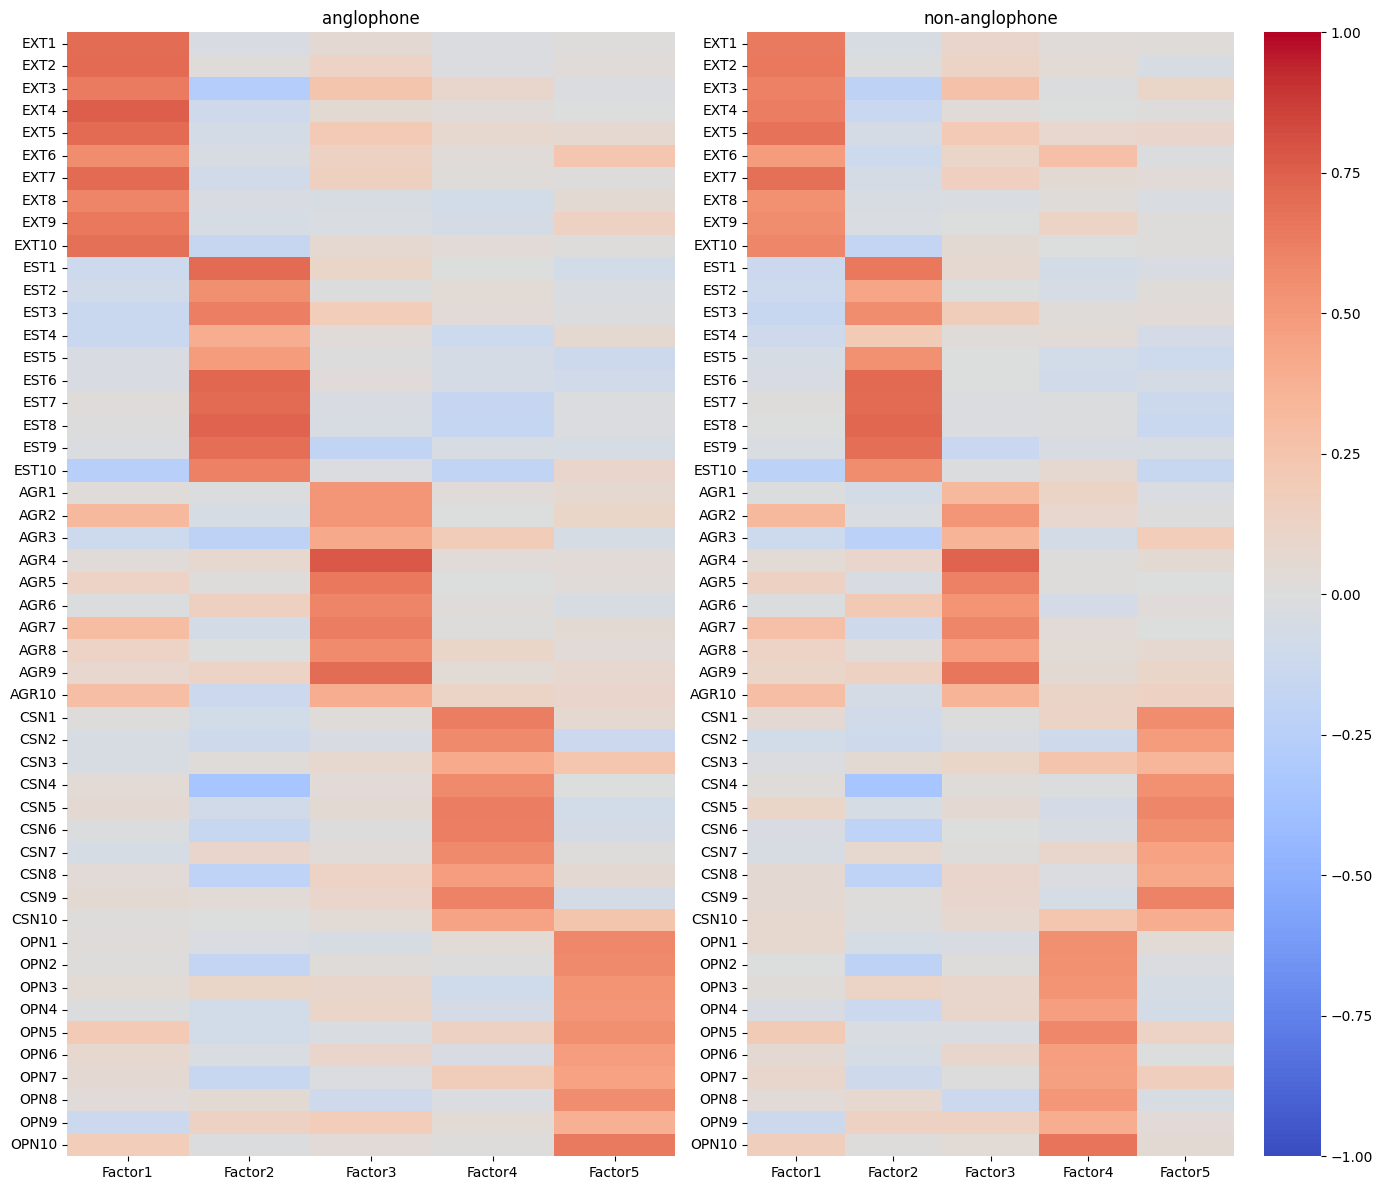

In [66]:
# here i want to compare the heatmaps between the anglaphone and non-anglophone
fig, axes = plt.subplots(1, 2, figsize=(14, 12))
sns.heatmap(anglo_loadings, cmap='coolwarm', center=0, vmin=-1, vmax=1, ax=axes[0], cbar=False)
axes[0].set_title('anglophone')
sns.heatmap(non_anglo_loadings, cmap='coolwarm', center=0, vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title('non-anglophone')
plt.tight_layout()
plt.show()

I think this is super interesting! I think it shows that within the context of this data there appears to be a structural difference between the linguistic divide for Openness and Concioenouness. From Reading the questions again and a cursory look at some articles on this topic the concesus is that this is because of the wordings of the questions. For example "I feel comfortable around people" (from EXT) translates much easier across linguistic and cultural spheres than questions like "I have a vivid imagination" (from OPN). This makes sense also because the survey and questions are designed for and from within an anglo-dominant perspective. This indicates a dofference in how the survey is interpritated - not a direct difference in personalities. Comparing just the English v Non-English perspective is obviously incredibly reductive and there is much space for exploring other linguistic differences.

Thank you for reading! :)